# 4 · Matrices & correlation

**Analytical question:** what structure is there across a two-way grid of values,
or across many variables at once?

## Charts in this notebook

| Function | Level | Dataset | In one line |
|---|---|---|---|
| `heatmap` (pivot) | axes | flights | a wide table of one value, encoded as colour |
| `heatmap` (correlation) | axes | california_housing | `df.corr()` drawn as colour, diverging around 0 |
| `clustermap` | figure | california_housing | the same matrix, rows/columns reordered by hierarchical clustering |

**Method:** `heatmap` gets its two standard uses (a pivot table and a
correlation matrix); `clustermap` is fed that same correlation matrix so the
"before / after reordering" comparison is direct. Each ends by saving a PNG to
`images/`.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from load_data import load_data

sns.set_theme(style="whitegrid")

flights = sns.load_dataset("flights")
housing = load_data("california_housing")

# The numeric columns of the housing data, and their correlation matrix —
# reused by the second heatmap and by clustermap.
housing_num = housing.select_dtypes("number")
housing_corr = housing_num.corr()

## `heatmap` — a pivot table

Axes-level. Takes data **already in wide / matrix form** and paints each value as
a coloured cell. You do the reshape (`pivot`, `crosstab`, `groupby().unstack()`)
first.

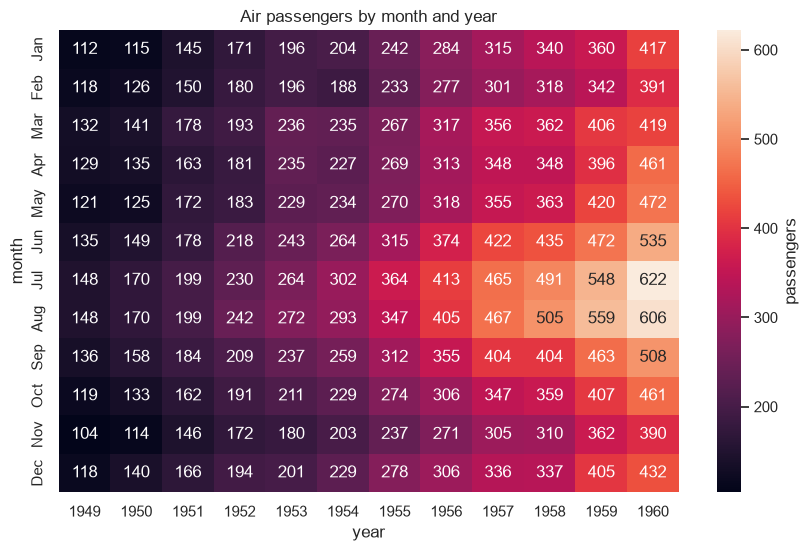

In [2]:
flights_wide = flights.pivot(index="month", columns="year", values="passengers")

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    flights_wide,
    annot=True, fmt="d",
    cmap="rocket",
    cbar_kws={"label": "passengers"},
    ax=ax,
)
ax.set_title("Air passengers by month and year")
fig.savefig("images/4_heatmap_pivot.png", dpi=150, bbox_inches="tight")

**Best for**

- Reading a pattern off a two-way grid at a glance — here the summer peak (rows) and the steady year-on-year growth (columns) are both obvious.
- `annot=True` prints the value in every cell (`fmt="d"`, `".2f"`, …) — legible up to a few dozen cells, not hundreds.
- Match the colormap to the data: a **sequential** ramp (`rocket`, `mako`, `viridis`) for magnitudes that build from a floor, as here.
- The palette changes for the next chart on purpose — it is a *diverging* one there, because correlations have a meaningful zero, while passenger counts do not. Matching the colormap to the data is the point, not consistency for its own sake.
- **Not** for continuous x / y — that is a 2-D histogram or `kdeplot`. And when exact numbers matter more than the shape, a plain table beats a heatmap.

[`heatmap` docs](https://seaborn.pydata.org/generated/seaborn.heatmap.html)

## `heatmap` — a correlation matrix

The other everyday use: `df.corr()` → `heatmap`, to see which variables move
together.

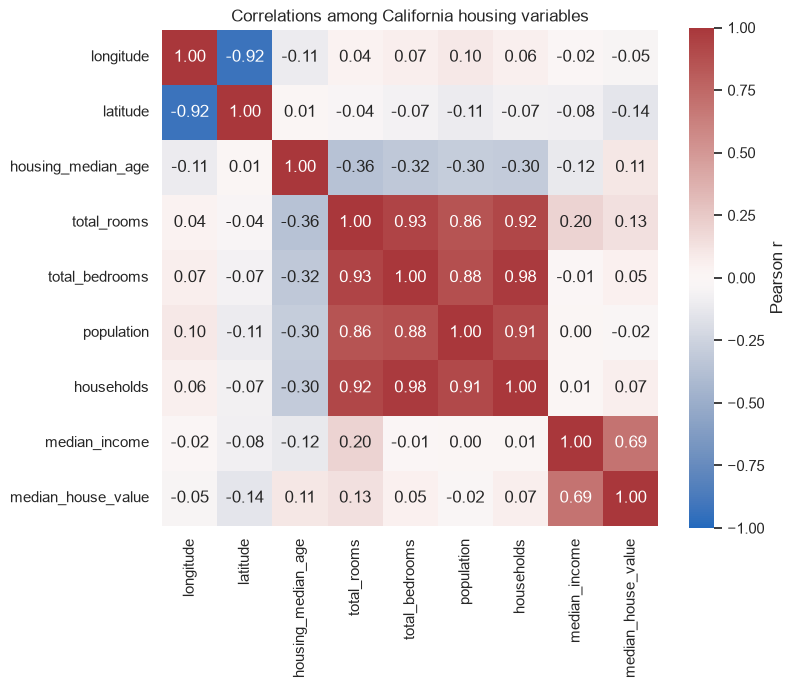

In [3]:
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(
    housing_corr,
    annot=True, fmt=".2f",
    cmap="vlag", center=0, vmin=-1, vmax=1,
    square=True,
    cbar_kws={"label": "Pearson r"},
    ax=ax,
)
ax.set_title("Correlations among California housing variables")
fig.savefig("images/4_heatmap_corr.png", dpi=150, bbox_inches="tight")

**Best for**

- A fast scan for redundancy and for likely predictors before modelling.
- Use a **diverging** palette with `center=0` (and `vmin=-1, vmax=1`) so +0.4 and −0.4 look equal-and-opposite and zero is colourless — a sequential ramp here would be misleading.
- `square=True` keeps the cells square; pass a triangular `mask` (via `np.triu`) to hide the redundant half.
- Read the blocks: `total_rooms`, `total_bedrooms`, `population` and `households` are all ~0.9 correlated (they all scale with block size) — a cue to combine or drop before a regression.

[`heatmap` docs](https://seaborn.pydata.org/generated/seaborn.heatmap.html)

## `clustermap`

Figure-level. A heatmap whose rows **and** columns are reordered by hierarchical
clustering, with dendrograms drawn on the margins. Fed the same correlation
matrix as above — so this is that heatmap, rearranged so related variables sit
together.

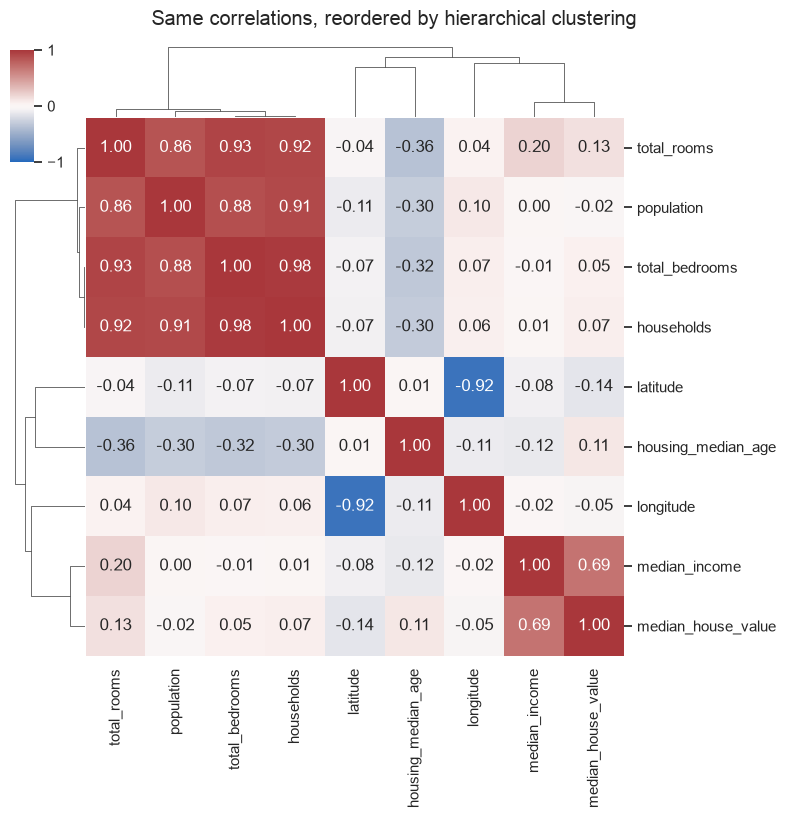

In [4]:
g = sns.clustermap(
    housing_corr,
    cmap="vlag", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f",
    figsize=(8, 8),
    dendrogram_ratio=0.12,
    cbar_pos=(0.02, 0.83, 0.03, 0.14),
)
g.figure.suptitle("Same correlations, reordered by hierarchical clustering", y=1.02)
g.savefig("images/4_clustermap.png", dpi=150, bbox_inches="tight")

**Best for**

- Letting the structure sort itself: similar rows / columns end up adjacent, so blocks of correlated variables form a visible square on the diagonal (here the four "size" columns collapse into one block, with `median_income` / `median_house_value` set apart).
- The dendrogram heights show *how* distinct the groups are.
- `z_score=` / `standard_scale=` to normalise before clustering; `method=` and `metric=` change the linkage; sample the rows first if the matrix is tall (distances are O(n²)).
- **Not** when the existing order carries meaning (time, rank, a designed sequence) — the reordering throws that away. Use a plain `heatmap` then.

[`clustermap` docs](https://seaborn.pydata.org/generated/seaborn.clustermap.html)